# Numpy

- It is used for mathematical operation in python.
- suppose we want to do matric multiplication or do average or something like that it would be very easy with Numpy.

# Pandas

- It is used for data manipulation and analyses.
- we used this in data cleaning and feature engineering to clean our data an all.

# Matplotlib

- It is used for data visualization.
- we can use multiple charts and bars for better understanding of data.

# Seaborn

- Also used for data visualization and built in top of Matplotlib.
- we can direclty work with pandas data and also we have better visualization in this.


# Conda Environment

- It is kind of isolated workspace where we can install specific python version with specific project.
- for example , project 1 we use python 3.10 and project 2 we use python 3.11


# Exercise 1: Data Exploration with Python

This notebook walks you through a structured exploration of the **Titanic** dataset.

This dataset contains a collection of passenger information from the RMS Titanic’s 1912 voyage.


## Task 1: Pandas aboard!

Download the **Titanic dataset** from Moodle and place it in your project folder. Then, import it into a pandas DataFrame.

_Note: Make sure that the package pandas is actually installed in the environment you are using!_


In [2]:
import pandas as pd

data = pd.read_csv("../data/titanic.csv")

## Task 2: First Look

Let’s take a **first look** at the data.

- Print out the number of rows and columns
- Print the column names
- Print the first 5 rows from the dataset
- Print the average age of the passengers
- Use `df.describe()` and explain the information you receive from the function call in your own words


In [3]:
# Print rows and columns
rows, columns = data.shape
print(f"Rows: {rows}" )
print(f"Columns: {columns}")

# Print Column names
column_names = data.columns
print(column_names)



Rows: 891
Columns: 12
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [4]:
# Print first 5 rows
data.head(5)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# Average age of the passengers
avg_age = data["Age"].mean()
print(avg_age)

29.69911764705882


In [6]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# It returns basic math calculations basically summary statistics


## Task 3: Iceberg Ahead – Missing Data!

Next, the dataset has to be cleaned appropriately.

- Print which columns contain missing data
- Replace missing values in the `age` column with the **mean age**.
- Drop columns with more than 50% of missing values.
- Drop rows that still contain missing values.
- Compare the number of rows and columns to the original dataset and describe the changes.

_Note: Use this cleaned dataset for the rest of the exercises!_


In [7]:
# Columns containing missing data
data.isnull().columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [8]:
# Replace missing value with mean in age columns
data["Age"]= data["Age"].fillna(data["Age"].mean())

In [9]:
# Drop columns with more than 50% of missing values
threshold = len(data)*0.5
data = data.dropna(thresh=threshold,axis=1)

In [10]:
# Drop rows that contains missing values
data = data.dropna()

In [11]:
# To check if there are still any missing values
data.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [12]:
data.shape

(889, 11)

BEFORE (891,12) -> AFTER (889,11)

It means that one columns is removed which is 'Cabin' and some raws containing missing values


## Task 4: Exploratory Filtering

- Check if the passenger with the **most expensive ticket** (`Fare`) survived.
- Print the names of the **oldest** passenger who survived.
- Group the passengers by ticket class (`Pclass`) and print the average `age`, as well as the respective survival rates for each class.


In [13]:
# Passenger with the most expensive ticket Survived or not
passenger_info = data.loc[data["Fare"].idxmax()]
if passenger_info["Survived"]==1 :
    print("passenger survived")
else:
    print("Not Survived")

passenger survived


In [14]:
# Name of the oldest survived person
pasenger_info = data.loc[data["Age"].idxmax()]
passenger_info["Name"]



'Ward, Miss. Anna'

In [15]:
result = data.groupby("Pclass").agg({
    "Age": "mean",
    "Survived": "mean"
})

print(result)

              Age  Survived
Pclass                     
1       36.927073  0.626168
2       29.866958  0.472826
3       26.403259  0.242363


## Task 5: Plotting

- Group passengers by `sex` and `ticket class` and compare the survival rates for each subgroup.
- Create a **bar plot** for visualisation!

_Hint: the seaborn package has built-in functions for plotting pandas dataframes!_


In [16]:
grouped = data.groupby(["Sex", "Pclass"])["Survived"].mean().reset_index()
print(grouped)

      Sex  Pclass  Survived
0  female       1  0.967391
1  female       2  0.921053
2  female       3  0.500000
3    male       1  0.368852
4    male       2  0.157407
5    male       3  0.135447


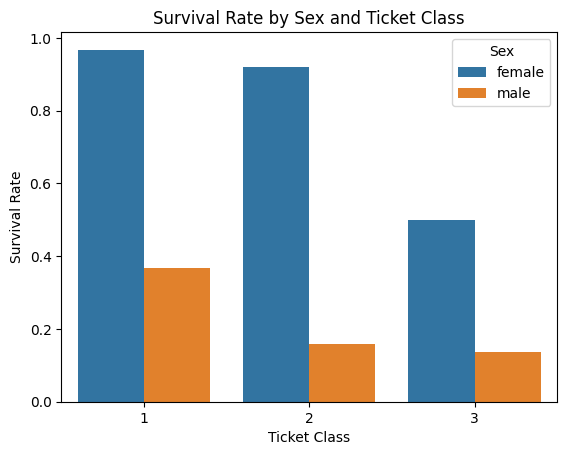

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=grouped, x="Pclass", y="Survived", hue="Sex")

plt.title("Survival Rate by Sex and Ticket Class")
plt.ylabel("Survival Rate")
plt.xlabel("Ticket Class")

plt.show()

## Task 6: Women and Children first

Did the **sex** and **age** of passengers influence the chance of survival?

- Validate your reasoning with one or more plots.
- Explain why you chose this form of visualization.
- Reflect: could replacing the missing ages in Task 2 have skewed your analysis?


I Think sex of passengers influence the chance of survival and age can also be a factor but passenger with higher class survices ration is more.

The reason for bar chart selection is becuase of clear difference visualization

Replacing the missing ages skewed our analysis that is what i think based on the data the survival rate of older and youger is more so in this data replacing null value with average is not good idea.
